In [1]:
words = open('names.txt','r').read().splitlines()
print(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett', 'victoria', 'madison', 'luna', 'grace', 'chloe', 'penelope', 'layla', 'riley', 'zoey', 'nora', 'lily', 'eleanor', 'hannah', 'lillian', 'addison', 'aubrey', 'ellie', 'stella', 'natalie', 'zoe', 'leah', 'hazel', 'violet', 'aurora', 'savannah', 'audrey', 'brooklyn', 'bella', 'claire', 'skylar', 'lucy', 'paisley', 'everly', 'anna', 'caroline', 'nova', 'genesis', 'emilia', 'kennedy', 'samantha', 'maya', 'willow', 'kinsley', 'naomi', 'aaliyah', 'elena', 'sarah', 'ariana', 'allison', 'gabriella', 'alice', 'madelyn', 'cora', 'ruby', 'eva', 'serenity', 'autumn', 'adeline', 'hailey', 'gianna', 'valentina', 'isla', 'eliana', 'quinn', 'nevaeh', 'ivy', 'sadie', 'piper', 'lydia', 'alexa', 'josephine', 'emery', 'julia', 'delilah', 'arianna', 'vivian', 'kaylee', 'sophie', 'brielle', 'madeline', 'peyton', 'ryle

In [ ]:
b = {}

for word in words:
    new_word = ['.'] + list(word) + ['.']

    for w1, w2 in zip(new_word, new_word[1:]):
        biagram = (w1, w2)
        b[biagram] = b.get(biagram, 0) + 1

In [ ]:
b

In [8]:
b = sorted(b.items(), key=lambda kv: -kv[1])

In [6]:
import torch

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [7]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [15]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

In [16]:
for (w1, w2), v in b:
    i1 = stoi[w1]
    i2 = stoi[w2]
    N[i1, i2] = +v

In [ ]:
N

In [22]:
itos = {i:s for s,i in stoi.items()}

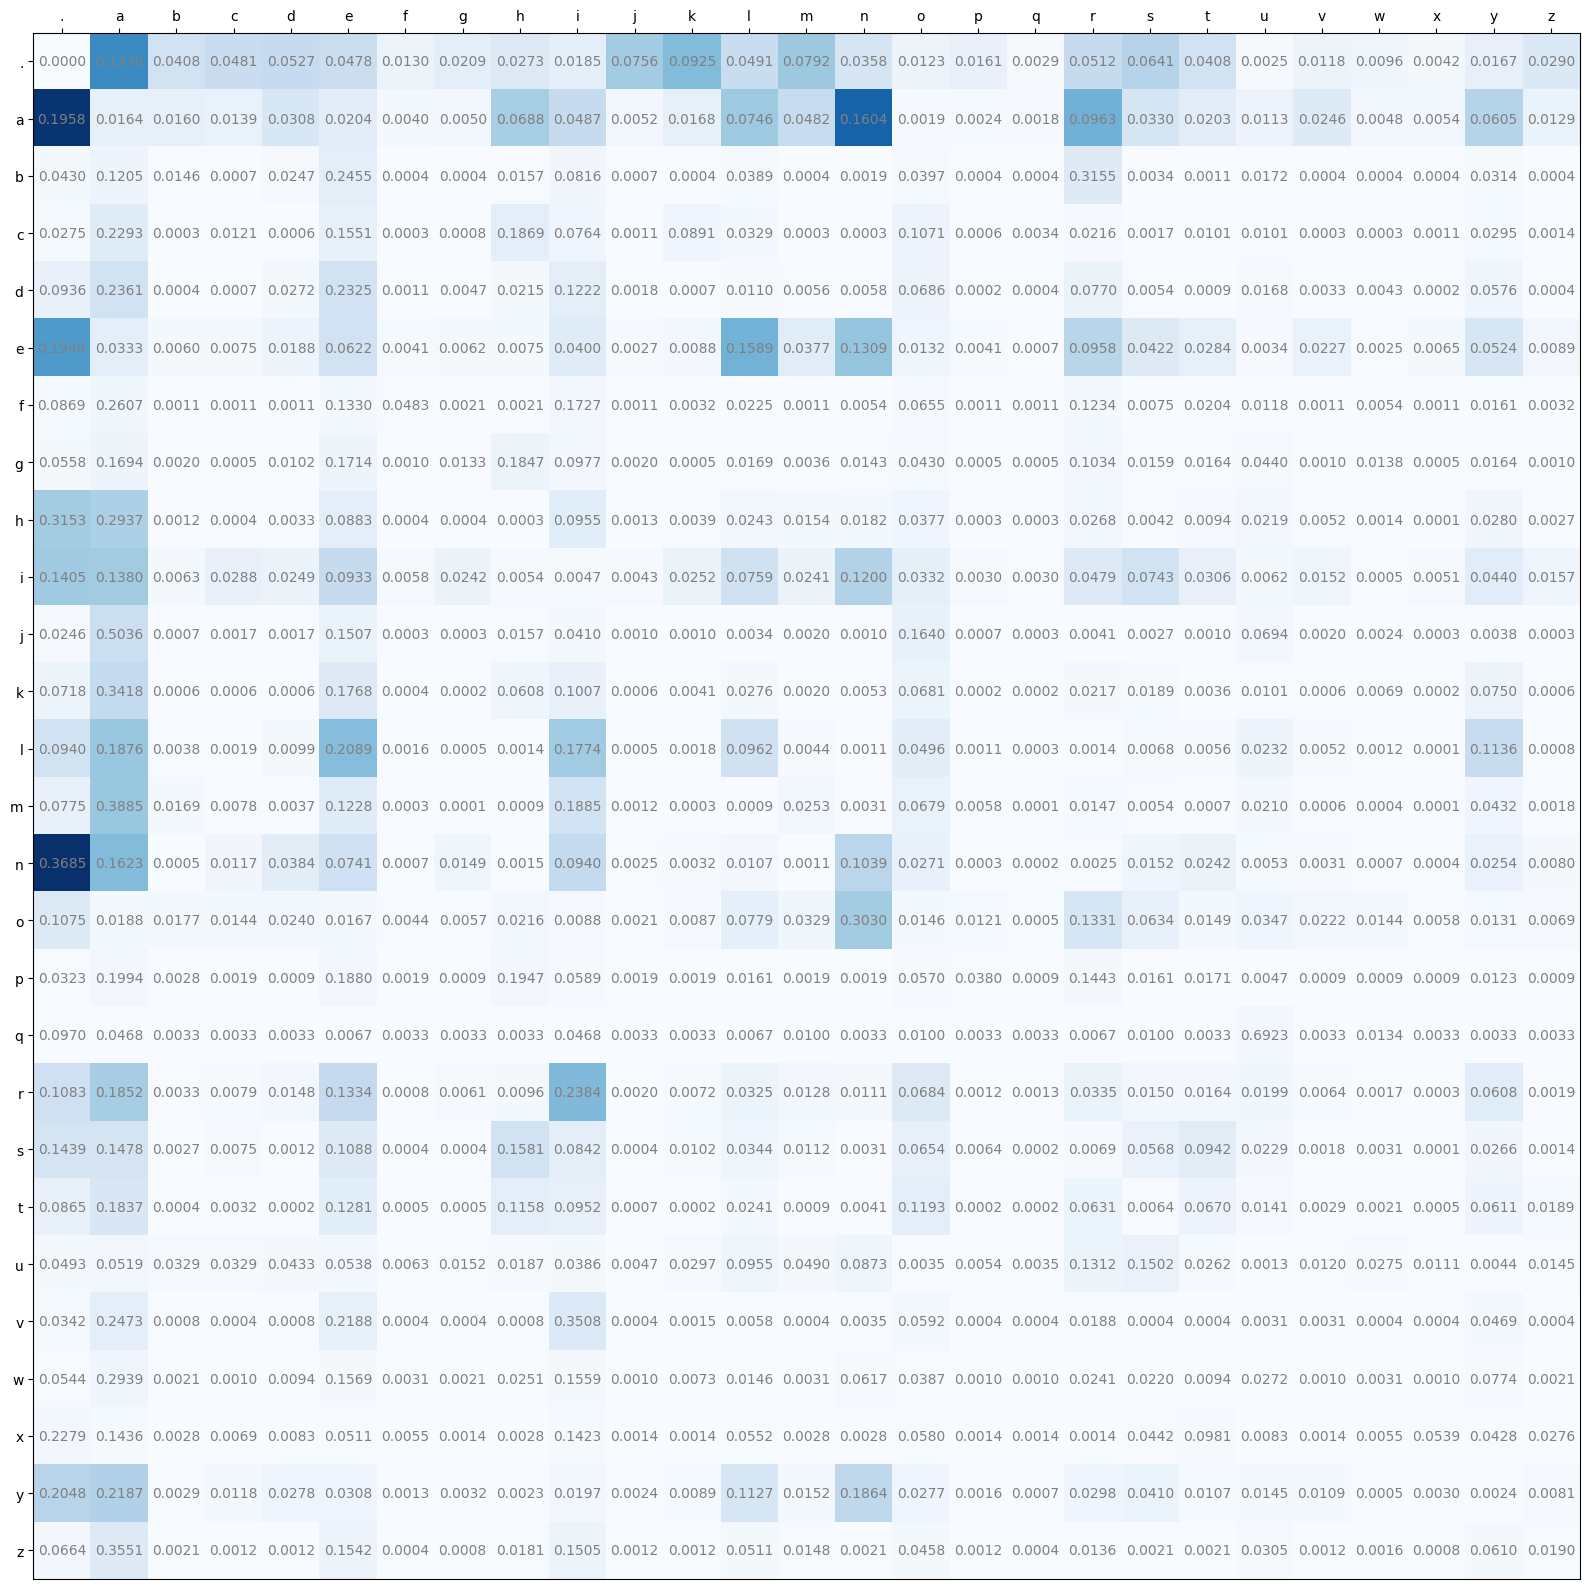

In [149]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')

# Create lists of labels for x and y axes using the itos mapping
x_labels = [itos[j] for j in range(27)]
y_labels = [itos[i] for i in range(27)]

# Set x-axis ticks and labels (top)
plt.xticks(range(27), x_labels, rotation=0) # Changed rotation from 90 to 0
plt.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

# Set y-axis ticks and labels (left)
plt.yticks(range(27), y_labels)
plt.tick_params(axis='y', left=True, labelleft=True, right=False, labelright=False)

# Loop through the matrix to display the counts inside each cell
for i in range(27):
  for j in range(27):
    plt.text(j, i, f"{p[i, j].item():.4f}", ha="center", va="center", color='gray')
# Remove any extra padding around the plot
plt.tight_layout()

In [70]:
p = N[0].float()
p = p/p.sum()
p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [71]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'j'

In [147]:
p = (N+1).float()
p /= p.sum(dim=1, keepdim=True)
p[0]

tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
        1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
        4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
        5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
        4.2109e-03, 1.6719e-02, 2.9008e-02])

In [ ]:
x = 0
for i in range(100):
    name = ''
    while True:
        x = torch.multinomial(p[x], num_samples=1, replacement=True, generator=g).item()
        name += itos[x]
    
        if x == 0:
            break
        
    print(name)

In [158]:
negative_likelihood = 0.0
n = 0
# for w in words:
for w in ['bharat']:
    chrs = ['.'] + list(w) + ['.']
    for w1, w2 in zip(chrs, chrs[1:]):
        stoi1 = stoi[w1]
        stoi2 = stoi[w2]
        prob = p[stoi1, stoi2]
        log_prob = torch.log(prob)
        negative_likelihood -= log_prob
        n+=1
        # print(f'{w1}{w2} : p={prob:.4f}, log(p)={log_prob:.4f}')
print(f'Negative log-likelihood: {negative_likelihood:.4f}')
print(f'Average negative log-likelihood per bigram: {negative_likelihood/n:.4f}')

Negative log-likelihood: 18.9504
Average negative log-likelihood per bigram: 2.7072


In [125]:
x = torch.tensor([[1., 2., 3.],
                   [4., 5., 6.],
                   [7., 8., 9.]]) 
y =x/ x.sum(dim=1, keepdim=False)
y

tensor([[0.1667, 0.1333, 0.1250],
        [0.6667, 0.3333, 0.2500],
        [1.1667, 0.5333, 0.3750]])

In [121]:
p.shape

torch.Size([27, 27])